# LSTM Networks

## Start with the problem: the important clue came much earlier

Imagine reading a machine's event history. A warning appears near the beginning, followed by many ordinary measurements. At the end, you must decide whether the run needs inspection. Counting warnings might help, but their order can matter: a warning followed by a repair is different from a repair followed by a warning.

A recurrent neural network reads one observation at a time and carries a hidden state forward. That state is a learned numerical summary of the history. In a vanilla RNN, the summary is repeatedly transformed and passed through an activation. Useful early information can become difficult to retain, and the gradients needed to learn from it can become small.

**Long short-term memory (LSTM)** adds a separate memory pathway and learned controls called gates. We will follow the controls, calculate a complete transition, watch memory change over several steps, and connect the states to a prediction and loss. These are small teaching calculations, not evidence that an LSTM will remember every important event.

Read [Recurrent Neural Networks](21_Recurrent_Neural_Networks_Notes.ipynb) and [Backpropagation Through Time](22_Backpropagation_Through_Time_Notes.ipynb) for the underlying recurrence and training. The [code companion](23_LSTM_Networks.ipynb) verifies the first calculation and fits a tiny order-classification task.


## See the memory pathway before opening the equations

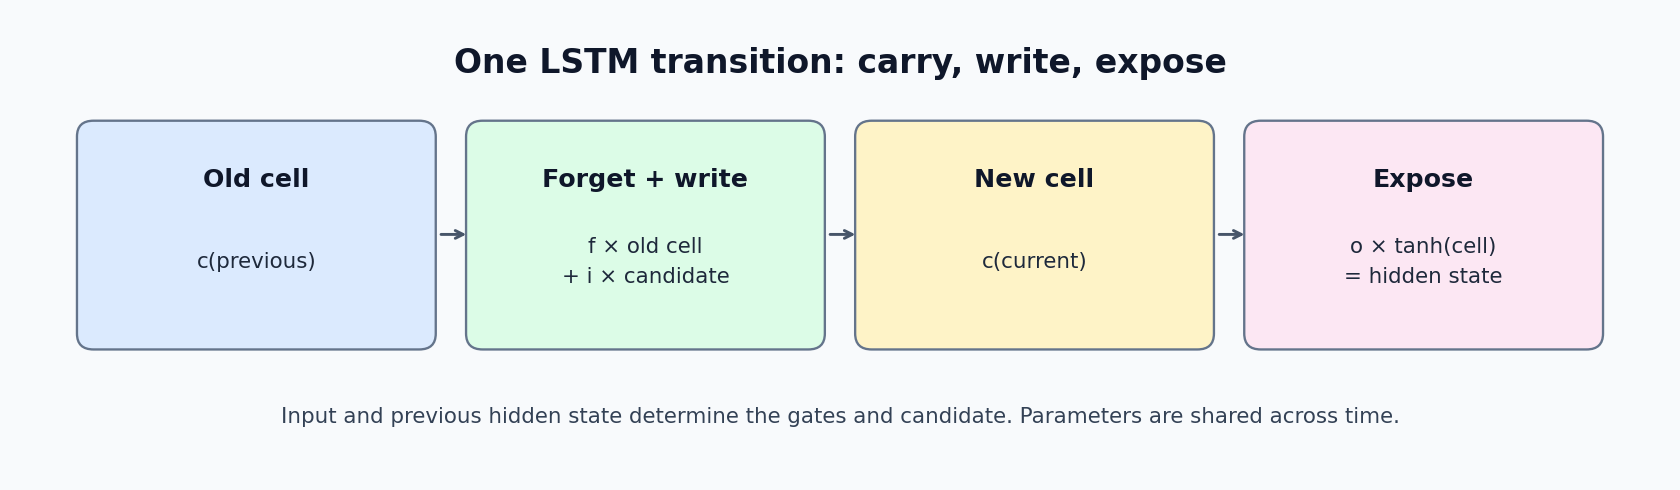

At each step the LSTM receives three things: the new input, the previous hidden state, and the previous cell state. It returns a new hidden state and a new cell state. The same learned parameters are reused at every position.

The cell is not a notebook of literal facts. It is a vector of numbers whose usefulness is shaped by training. A hidden dimension might respond to a useful combination of events, but it does not automatically correspond to a named concept such as “repair completed.”

> **Main idea:** retain selected old information, add selected new information, and expose a selected view of the result.


## Separate what is stored from what is exposed

| Symbol | Meaning | Shape for one example |
| --- | --- | --- |
| $x_t$ | Input features at position $t$ | $D$ |
| $h_{t-1}$ | Previous hidden state | $H$ |
| $c_{t-1}$ | Previous cell state | $H$ |
| $f_t,i_t,o_t$ | Forget, input, and output gates | $H$ each |
| $g_t$ | Candidate cell content | $H$ |
| $c_t$ | Updated cell state | $H$ |
| $h_t$ | Updated hidden state | $H$ |

$D$ is the number of input features and $H$ is the hidden width. The cell and hidden state have the same width in this standard, unprojected LSTM, but different roles. The cell provides a path for carrying information forward. The hidden state is the exposed representation used by the next transition and often by an output head.

Initial states are commonly zeros for independent examples. They can also be learned or supplied by an earlier chunk of the same stream. Carrying states from one independent person or document into another would change the problem by mixing their histories.


## Gates are continuous controls learned from the input

A sigmoid turns an unrestricted score into a number between zero and one:

$$\sigma(a)=\frac{1}{1+e^{-a}}.$$

For example, $\sigma(0)=0.5$, $\sigma(2)\approx0.881$, and $\sigma(-2)\approx0.119$. Multiplying a value by 0.5 keeps half of it; multiplying by 0.881 keeps most of it. A gate does not need to make a hard yes/no decision.

The candidate uses $\tanh$, whose output lies between $-1$ and $1$. It can propose positive or negative content. Sigmoid gates control the amount of this content rather than its sign.

| Component | Question answered | Effect |
| --- | --- | --- |
| Forget gate | How much old cell content should remain? | Scales $c_{t-1}$ |
| Input gate | How much candidate content should be written? | Scales $g_t$ |
| Candidate | What new content might be useful? | Supplies a signed proposal |
| Output gate | How much transformed cell content should be exposed? | Scales $\tanh(c_t)$ |

Each entry of a gate vector can make a different decision. One memory coordinate can be retained while another is rewritten. The gates are outputs of the network, not settings a person chooses for each real observation.


## Build the four learned calculations

For each component, combine the current input and previous hidden state:

$$f_t=\sigma(W_f x_t+U_f h_{t-1}+b_f),$$
$$i_t=\sigma(W_i x_t+U_i h_{t-1}+b_i),$$
$$g_t=\tanh(W_g x_t+U_g h_{t-1}+b_g),$$
$$o_t=\sigma(W_o x_t+U_o h_{t-1}+b_o).$$

The input matrices $W$ have shape $H\times D$; the recurrent matrices $U$ have shape $H\times H$; each bias has $H$ entries. The different subscripts identify different learned parameters. All four components inspect the same input and previous hidden state, but they need not produce similar answers.

Then update the states:

$$c_t=f_t\odot c_{t-1}+i_t\odot g_t,$$
$$h_t=o_t\odot\tanh(c_t).$$

$\odot$ means elementwise multiplication. This is not a matrix product: gate entry $j$ scales state entry $j$. Adding the retained content and the new write produces the updated cell. The output gate acts after that addition.

A standard LSTM does not feed the previous cell directly into the gate affine transforms above. Variants with peephole connections do, but they are a different parameterization.


## Calculate one transition completely

Use the same scalar example as the code companion. Start with $c_0=0.5$. Suppose the learned affine calculations have already produced $a_f=a_i=a_o=0$ and $a_g=1$. We choose these scores to expose the arithmetic; we are not claiming they were obtained by training.

| Calculation | Substitution | Result |
| --- | --- | --- |
| Forget gate | $\sigma(0)$ | $0.5$ |
| Input gate | $\sigma(0)$ | $0.5$ |
| Candidate | $\tanh(1)$ | $0.761594$ |
| Output gate | $\sigma(0)$ | $0.5$ |
| Retained memory | $0.5\times0.5$ | $0.25$ |
| New write | $0.5\times0.761594$ | $0.380797$ |
| New cell | $0.25+0.380797$ | $0.630797$ |
| New hidden state | $0.5\tanh(0.630797)$ | $0.279300$ |

The new cell is larger than the old one because the write exceeds the amount forgotten. The hidden state is smaller than the cell because tanh compresses its value and the output gate scales the result.

Notice the order of operations. Applying tanh separately to the two contributions and adding them would be a different computation. Also, the cell is not restricted to $[-1,1]$: repeated writes can accumulate. The hidden state is bounded by the tanh and output gate in this standard formulation.


## Follow memory across several observations

Now imagine three more transitions with selected gate outputs. These choices illustrate retention, revision, and exposure; a trained model must learn when to use each behavior.

| Step | Forget $f$ | Input $i$ | Candidate $g$ | Output $o$ | Retained part | Write | Cell $c$ | Hidden $h$ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 0.50 | 0.50 | 0.761594 | 0.50 | 0.250000 | 0.380797 | 0.630797 | 0.279300 |
| 2 | 0.90 | 0.10 | 0.20 | 0.80 | 0.567717 | 0.020000 | 0.587717 | 0.422602 |
| 3 | 0.95 | 0.05 | -0.40 | 0.30 | 0.558332 | -0.020000 | 0.538332 | 0.147517 |
| 4 | 0.20 | 0.80 | -0.70 | 0.90 | 0.107666 | -0.560000 | -0.452334 | -0.381434 |

For step 2, $c_2=0.9(0.630797)+0.1(0.2)=0.587717$. Most previous content survives. At step 3, memory remains positive, but the smaller output gate exposes less of it. A small hidden value therefore does not necessarily mean that the cell has forgotten everything.

At step 4, the old cell contributes little and a large negative write changes the sign. Forgetting can be useful: the model should be able to revise an outdated summary when a new event changes the meaning of the history.


## Distinguish retention, writing, and exposure visually

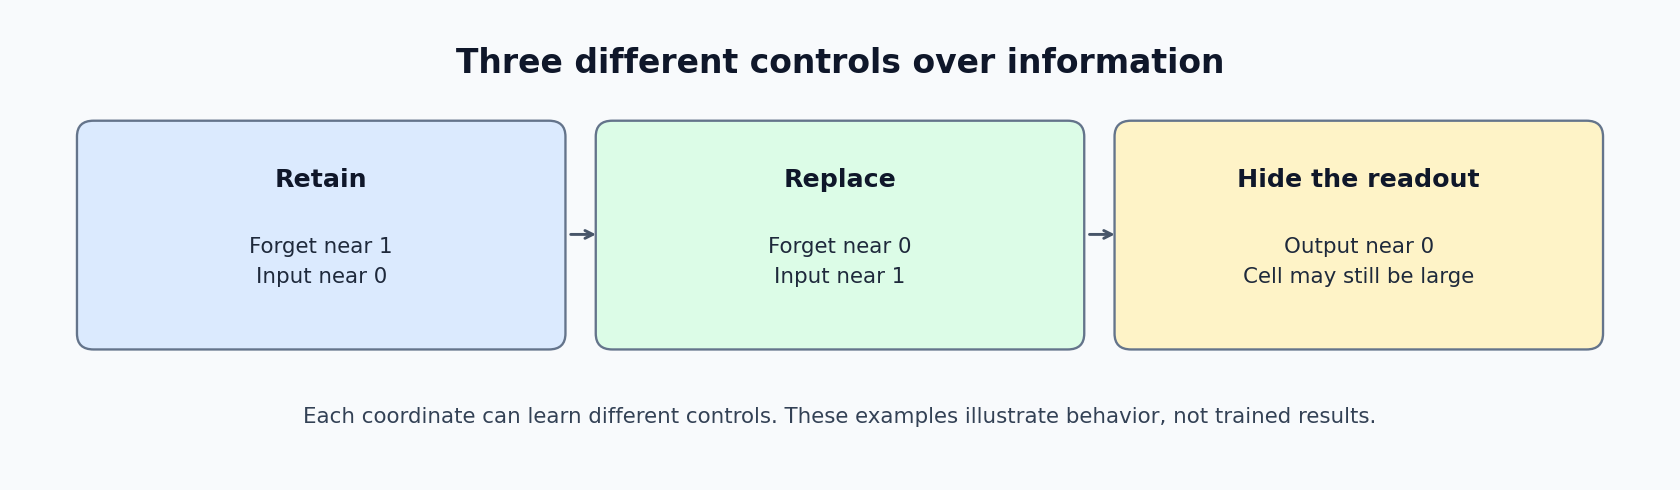

Consider three limiting cases. If $f$ is near one and $i$ near zero, the cell mostly carries its old value forward. If $f$ is near zero and $i$ near one, the candidate mostly replaces it. If $o$ is near zero, the hidden readout is small even when the cell contains a substantial value.

These cases explain the roles of the controls, but do not prescribe what a real model must learn. An output gate near zero also affects the hidden state supplied to later gate calculations. The cell path and hidden path interact, so changing one control can influence future behavior.

A scalar diagram is a useful simplification. In a vector LSTM, all three behaviors can happen simultaneously in different coordinates.


## Connect a hidden state to a prediction and loss

The recurrent layer produces a representation. A separate task head turns that representation into a prediction. For a scalar binary example, choose output weight $v=2$ and output bias $b=-0.1$:

$$q=vh_1+b=2(0.279300)-0.1\approx0.458601,$$
$$p=\sigma(q)\approx0.612682.$$

If the true class is one, binary cross-entropy is $L=-\ln(p)\approx0.489909$. The derivative with respect to the head score is $\partial L/\partial q=p-1\approx-0.387318$.

The head weight gradient is $(p-1)h_1\approx-0.108178$, and the head bias gradient is $p-1$. An SGD step with learning rate 0.1 changes $v$ to approximately 2.010818 and $b$ to -0.061268. Holding the recurrent representation fixed, the new score is about 0.500354, increasing the probability of the correct class.

This update illustrates only the output head. Full training also differentiates through $h_1$, the cell update, and the gate calculations. With a longer sequence, it follows those dependencies across time and sums contributions to the shared recurrent parameters.


## Understand the gradient route through the cell

Holding the gate outputs fixed, the direct derivative of the new cell with respect to the old cell is $f_t$. Across $k$ steps, this particular path contains the product of the intervening forget gates.

| Constant forget value | Direct retention factor after 10 steps | Interpretation |
| --- | --- | --- |
| 0.50 | $0.5^{10}\approx0.000977$ | Strong decay |
| 0.90 | $0.9^{10}\approx0.348678$ | Some signal remains |
| 0.99 | $0.99^{10}\approx0.904382$ | Much of this path remains |

This additive cell pathway can help a gradient reach earlier events. It avoids applying a new tanh to the entire cell at every carry operation. But the table is not the complete recurrent derivative: gates depend on hidden states, hidden states depend on cells, and additional paths contribute.

LSTMs can still have vanishing or exploding gradients. Saturated gate activations can make gate parameters difficult to adjust. Gradient clipping can limit a large update but cannot recover information that the model failed to preserve. Backpropagation through time remains the training algorithm.


## Read the tensor shapes in the companion

For the companion's one-layer, unidirectional, unprojected LSTM, input size is 1 and hidden size is 3. One example has four observations.

| Object | Shape | Meaning |
| --- | --- | --- |
| Input with `batch_first=True` | $(1,4,1)$ | Batch, time, features |
| Output sequence | $(1,4,3)$ | Hidden representation at every position |
| Final hidden state | $(1,1,3)$ | Layer/direction, batch, hidden |
| Final cell state | $(1,1,3)$ | Layer/direction, batch, cell |

The leading dimension of the returned final states is not the batch dimension. Setting `batch_first=True` changes the input/output sequence layout, not this state layout. For this unpadded, single-direction example, the last output equals the final hidden state.

If layers or directions are added, state interpretation must account for them. A bidirectional layer reads both directions and is appropriate when the whole sequence is available, such as offline labeling. It cannot be used to read unknown future events in an online forecast.


## Choose the readout for the prediction you need

| Task | Readout | Typical head output |
| --- | --- | --- |
| Classify a whole sequence | Last valid hidden state or a masked summary | One class distribution |
| Label each observation | Hidden state at each valid position | One distribution per position |
| Predict the next value | Representation of the observed prefix | One numerical forecast |
| Predict several future values | Prefix representation or recurrent decoder | A defined forecast horizon |

A final-state classifier asks the recurrent state to retain everything needed for the decision. Masked mean pooling combines representations across valid positions. An attention readout learns which positions to emphasize. These choices change how the prediction receives evidence; none is universally best.

For a two-class head, use two logits and cross-entropy with an integer target. The logits do not need a separate softmax before a loss that already handles it. For numerical forecasting, use a regression head and a loss appropriate to the units and task.


## Padding is a batching convenience, not another event

Suppose one sequence has length three and another length five. Padding the shorter sequence to five makes a rectangular batch, but its last two positions are not observations.

| Example | Stored positions | Valid length | Correct final observation index |
| --- | --- | --- | --- |
| A | warning, repair, normal, PAD, PAD | 3 | 2 |
| B | normal, warning, normal, repair, normal | 5 | 4 |

Reading `outputs[:, -1]` for A would use a state after processing padding. Even zero padding can change the state through biases and recurrent transforms. A loss mask prevents padded labels from contributing to the objective; it does not itself prevent a recurrent layer from processing padded inputs.

For a forward-only layer, gathering the output at `length - 1` gives the last valid output. Packed sequences can avoid recurrent work on padded steps. For bidirectional layers, padding can also affect reverse-direction states, so correctly handling lengths during recurrence is especially important.


## Inspect what the toy order classifier actually establishes

The companion places a marker and distractor at fixed positions in length-six sequences. Both classes have the same event counts. Their distinguishing information is whether the marker comes before or after the distractor.

The classifier uses two input features, eight hidden units, and a two-logit head. Its training loop clears gradients, computes cross-entropy, backpropagates, and applies an Adam update. The final sequence output feeds the head because all examples have the same valid length.

There are repeated copies of only two templates. High training accuracy confirms that the model can fit this tiny order distinction. It does not demonstrate long-term memory on unfamiliar sequences or accuracy on a held-out population.

A stronger experiment would vary event positions, sequence lengths, distractors, and noise, then hold out genuinely different templates or sources. Compare against a count-based baseline and a simpler recurrent model to determine which structure the task actually needs.


## Compare the recurrent alternatives fairly

| Property | Vanilla RNN | LSTM | GRU |
| --- | --- | --- | --- |
| Persistent state | Hidden | Hidden and cell | Hidden |
| Main update | Nonlinear recurrent transform | Gated carry, write, and exposure | Gated blend with a reset-controlled candidate |
| Affine blocks per layer | 1 | 4 | 3 |
| Useful starting point | Short dependencies and compact baseline | Tasks needing flexible memory control | Compact gated baseline |

For a standard layer with one bias per affine block, the parameter counts are $H(D+H+1)$, $4H(D+H+1)$, and $3H(D+H+1)$ respectively. Libraries may store separate input and recurrent biases, changing the exact count. An output head adds its own parameters.

More gates do not guarantee a better result. Compare validation quality, latency, memory, and robustness with comparable experimental budgets. Recurrent steps are sequential even though calculations within a step can be parallelized. [GRU Networks](24_GRU_Networks_Notes.ipynb) explores the smaller gated alternative.


## Diagnose common mistakes before changing the architecture

| Symptom or mistake | Likely question to investigate | Useful check |
| --- | --- | --- |
| Good training score, weak validation | Are templates or sources repeated? | Split by independent source or time |
| Short examples work, long ones fail | Is useful information preserved? | Evaluate by length and dependency distance |
| Predictions change with extra padding | Does the readout use padded positions? | Check lengths and recurrence handling |
| Sudden unstable loss | Are gradients or input scales large? | Inspect norms, scaling, and learning rate |
| Histories influence unrelated examples | Are states carried across boundaries? | Reset states for independent sequences |

For long streams, carrying numerical states and carrying the entire computation graph are different decisions. Detaching a state preserves its value but cuts the gradient connection into earlier chunks. This is truncated BPTT, not full long-history gradient training.

Do not add complexity until the target alignment, split, input scale, and readout are correct. A sophisticated memory mechanism cannot repair a prediction task defined with the wrong targets.


## Check your understanding and keep the core idea

1. With $c_{t-1}=0.8$, $f_t=0.9$, $i_t=0.1$, and $g_t=-0.2$, what is $c_t$?
2. If only the output gate changes, does the current cell update change?
3. Why can the final stored position be the wrong readout for a shorter padded example?
4. Does fitting two repeated order templates establish performance on unseen histories?

**Answers.** The new cell is $0.9(0.8)+0.1(-0.2)=0.70$. Changing only the current output gate changes the current hidden readout, not the current cell formula; later steps can still be affected through that hidden state. The final stored position may be padding rather than the final observation. Repeated-template training accuracy establishes fitting behavior on those templates, not generalization.

**Remember:** an LSTM learns how much old cell content to retain, what new content to write, and how much to expose. Understanding these three controls is more useful than memorizing the name of the architecture.

Continue with [GRU Networks](24_GRU_Networks_Notes.ipynb), then [Sequence Modeling](25_Sequence_Modeling_Notes.ipynb) for task alignment and evaluation. Implementation reference: [PyTorch LSTM documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html).
